⏳ PHASE 1: Running Triple Benchmark (75 total experiments)...
-> Testing Exponential domain...
-> Testing Logarithmic domain...
-> Testing Fourier domain...

🏆 --- TOP 5 RANKED FOR EXPONENTIAL --- 🏆
 Act  Loss  Final_RE  Time_Sec
Mish Huber  0.002333      1.25
Tanh Huber  0.002348      0.58
GELU  MSLE  0.003092      0.70
Mish   MSE  0.003628      1.30
GELU Huber  0.004509      0.69

🏆 --- TOP 5 RANKED FOR LOGARITHMIC --- 🏆
  Act  Loss  Final_RE  Time_Sec
 Mish Huber  0.001572      1.35
 GELU Huber  0.001661      0.65
 Mish   MSE  0.001850      1.35
 Tanh Huber  0.002206      0.63
Swish Huber  0.002389      0.61

🏆 --- TOP 5 RANKED FOR FOURIER --- 🏆
  Act  Loss  Final_RE  Time_Sec
 Tanh Huber  0.061939      0.63
 Tanh   MSE  0.069336      0.57
 GELU Huber  0.104139      0.65
 Mish   MSE  0.111437      1.41
Swish Huber  0.127394      0.63

PHASE 2: INTERACTIVE DEMO MODE (Type '0' to exit)



Select Activation (1:ReLU, 2:Tanh, 3:Swish, 4:Mish, 5:GELU, 0:Exit):  1
Select Backprop Method (1:MSE, 2:MAE, 3:Huber, 4:MSLE, 5:RE):  1



Training ReLU + MSE live...


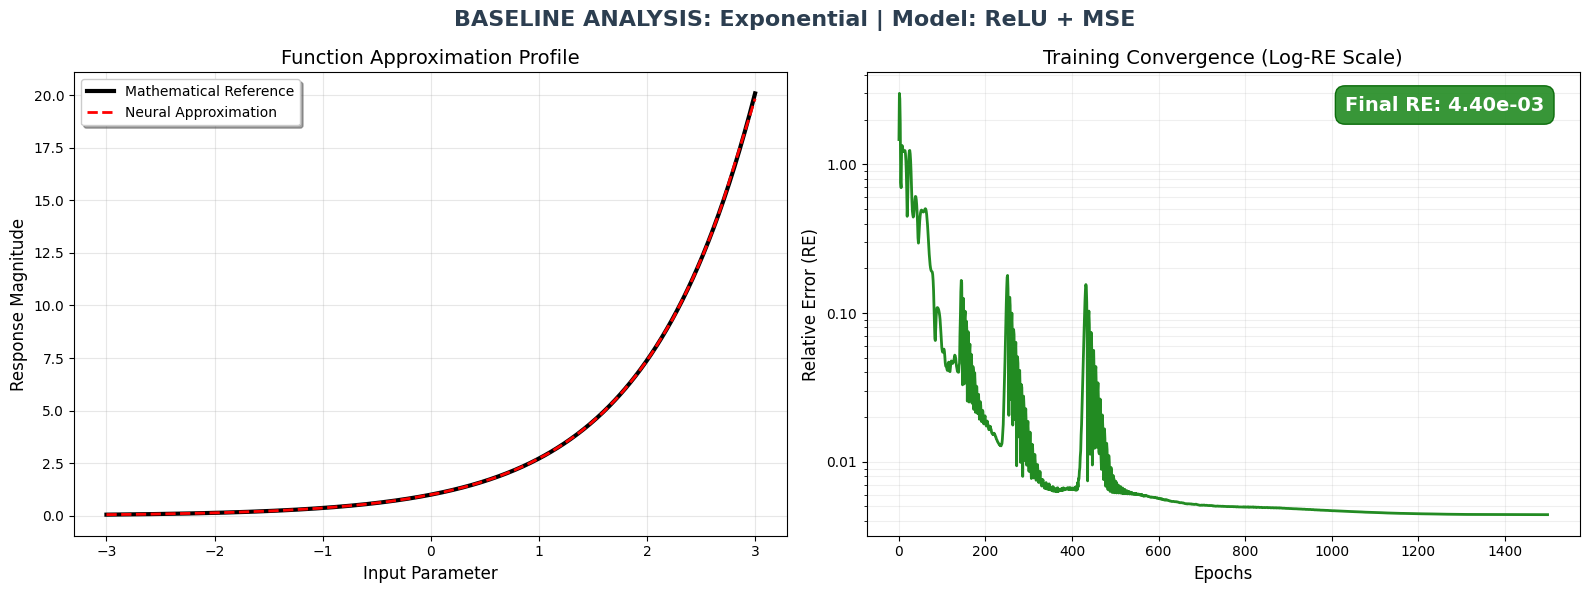

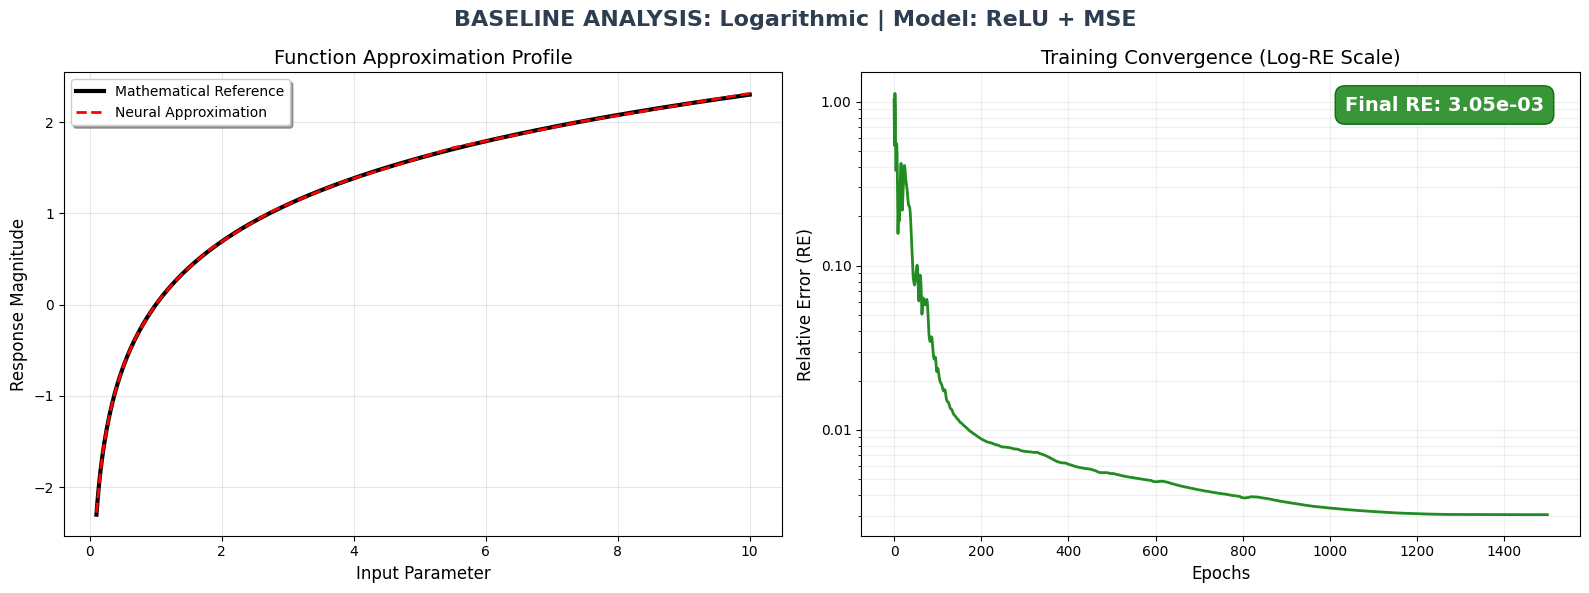

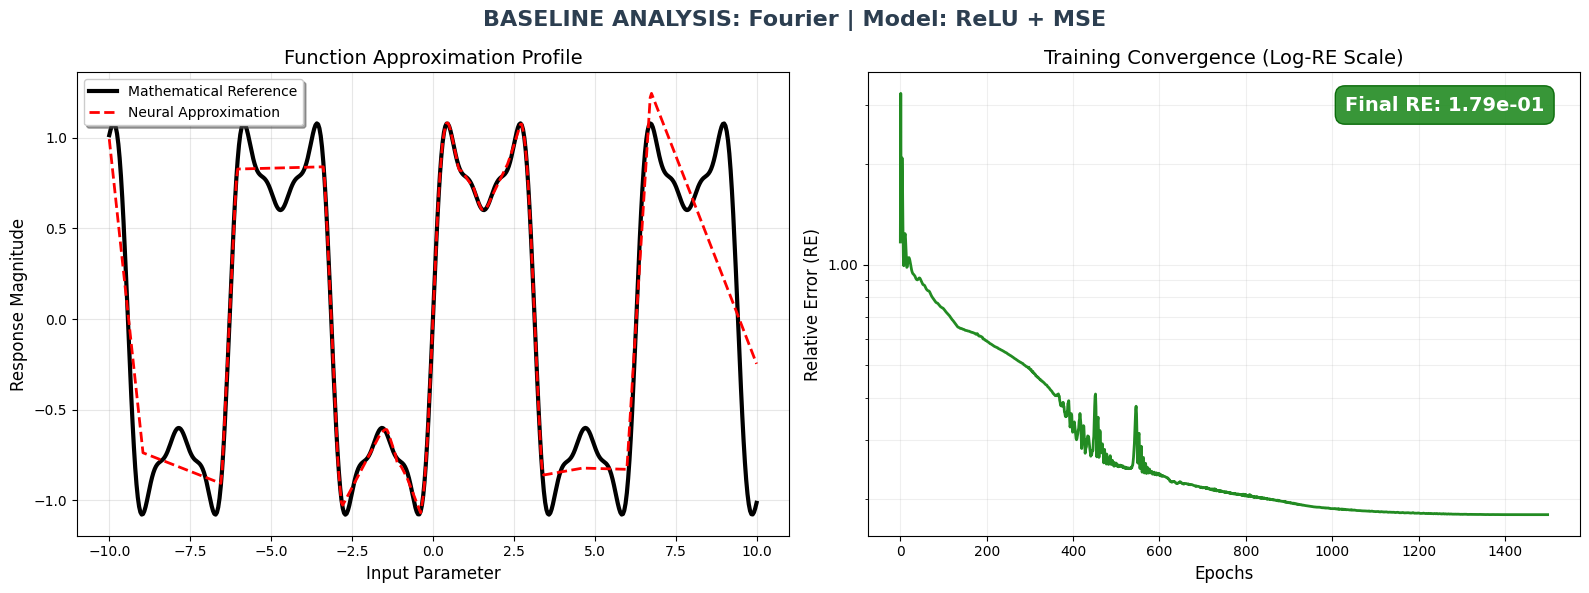

In [ ]:
"""
Phase 2: Architectural Optimization (The Tournament)
Project: Learning Constitutive Laws in 2D Granular Flow
Author: Abhishek Tagalpallewar

Description:
This script conducts a systematic 'Tournament' across 75 unique hyperparameter 
combinations (5 Activations x 5 Loss Functions x 3 Domains). It evaluates 
which architecture best captures the non-linearities of physical systems 
before we deploy onto real LAMMPS granular data[cite: 3].
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import pandas as pd
import time

# --- 1. ARCHITECTURE & UTILITIES ---

class ResearchNet(nn.Module):
    """
    Standardized 3-layer architecture (64 nodes) identified in Phase I 
    as the optimal balance between modeling capacity and computational speed[cite: 3].
    """
    def __init__(self, act_fn):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), act_fn,
            nn.Linear(64, 64), act_fn,
            nn.Linear(64, 1)
        )
    def forward(self, x): 
        return self.net(x)

def get_data(func_name):
    """
    Generates three domains representing different physical challenges:
    - Exponential: Simulates rapid growth/dissipation in granular energy.
    - Logarithmic: Simulates asymptotic pressure baselines.
    - Fourier: Simulates complex oscillations found in force chains[cite: 3].
    """
    if func_name == 'Exponential':
        x = torch.linspace(-3, 3, 500).view(-1, 1)
        y = torch.exp(x)
    elif func_name == 'Logarithmic':
        x = torch.linspace(0.1, 10, 500).view(-1, 1)
        y = torch.log(x)
    elif func_name == 'Fourier':
        # High-frequency series to benchmark model depth and resolution
        x = torch.linspace(-10, 10, 500).view(-1, 1)
        y = torch.sin(x) + 0.5*torch.sin(3*x) + 0.2*torch.sin(5*x) + 0.1*torch.sin(7*x)
    return x, y

def get_loss_fn(idx):
    """Mapping index to professional loss objectives[cite: 3]."""
    methods = {
        1: nn.MSELoss(),         # Mean Squared Error
        2: nn.L1Loss(),          # Mean Absolute Error
        3: nn.HuberLoss(delta=1.0), # Hybrid MSE/MAE for outlier robustness[cite: 3]
        4: lambda p, t: torch.mean((torch.log1p(torch.abs(p)) - torch.log1p(torch.abs(t)))**2), # MSLE
        5: lambda p, t: torch.mean(torch.abs(p - t) / (torch.abs(t) + 1e-8)) # Relative Error (RE)
    }
    return methods[idx]

act_names = {1: 'ReLU', 2: 'Tanh', 3: 'Swish', 4: 'Mish', 5: 'GELU'}
act_map = {1: nn.ReLU(), 2: nn.Tanh(), 3: nn.SiLU(), 4: nn.Mish(), 5: nn.GELU()}
loss_names = {1: 'MSE', 2: 'MAE', 3: 'Huber', 4: 'MSLE', 5: 'RE'}

# ---------------------------------------------------------
# PHASE 1: TRIPLE LEADERBOARD (Automated Grid Search)
# ---------------------------------------------------------
print("⏳ PHASE 1: Running Triple Benchmark (75 total experiments)...")
all_benchmarks = []

for func_name in ['Exponential', 'Logarithmic', 'Fourier']:
    print(f"-> Testing {func_name} domain...")
    for a_idx, a_fn in act_map.items():
        for l_idx in range(1, 6):
            start_t = time.time()
            x_t, y_t = get_data(func_name)
            
            # Setup fresh model for each combo to ensure zero bias
            m = ResearchNet(a_fn)
            opt = optim.AdamW(m.parameters(), lr=0.01) # AdamW for decoupled weight decay
            
            # 1000 epochs for a solid engineering benchmark
            for _ in range(1000):
                opt.zero_grad()
                l = get_loss_fn(l_idx)(m(x_t), y_t)
                l.backward()
                opt.step()
                
            with torch.no_grad():
                pred = m(x_t)
                # Final ranking based on Relative Error (RE) for scale-invariance[cite: 3]
                re = torch.mean(torch.abs(pred - y_t) / (torch.abs(y_t) + 1e-8)).item()
            
            all_benchmarks.append({
                'Function': func_name,
                'Act': act_names[a_idx],
                'Loss': loss_names[l_idx],
                'Final_RE': re,
                'Time_Sec': round(time.time() - start_t, 2)
            })

# --- DISPLAYING THE RANKED TABLES ---
full_df = pd.DataFrame(all_benchmarks)

for func_name in ['Exponential', 'Logarithmic', 'Fourier']:
    print(f"\n🏆 --- TOP 5 RANKED FOR {func_name.upper()} --- 🏆")
    func_df = full_df[full_df['Function'] == func_name].sort_values('Final_RE')
    print(func_df[['Act', 'Loss', 'Final_RE', 'Time_Sec']].head(5).to_string(index=False))

# ---------------------------------------------------------
# PHASE 2: INTERACTIVE DEMO (Visualization & Presentation)
# ---------------------------------------------------------
print("\n" + "="*60)
print("PHASE 2: INTERACTIVE DEMO MODE (Type '0' to exit)")
try:
    while True:
        try:
            act_choice = int(input("\nSelect Activation (1:ReLU, 2:Tanh, 3:Swish, 4:Mish, 5:GELU, 0:Exit): "))
            if act_choice == 0: break
            
            loss_choice = int(input("Select Backprop Method (1:MSE, 2:MAE, 3:Huber, 4:MSLE, 5:RE): "))
            
            print(f"\nTraining {act_names[act_choice]} + {loss_names[loss_choice]} live...")
            
            for func in ['Exponential', 'Logarithmic', 'Fourier']:
                x_train, y_true = get_data(func)
                model = ResearchNet(act_map[act_choice])
                criterion = get_loss_fn(loss_choice)
                
                optimizer = optim.AdamW(model.parameters(), lr=0.01)
                # Cosine Annealing ensures we settle precisely into the global minimum[cite: 3]
                scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1500)

                re_history = []
                for _ in range(1500):
                    optimizer.zero_grad()
                    pred = model(x_train)
                    loss = criterion(pred, y_true)
                    loss.backward()
                    optimizer.step()
                    scheduler.step()
                    
                    with torch.no_grad():
                        re = torch.mean(torch.abs(pred - y_true) / (torch.abs(y_true) + 1e-8)).item()
                        re_history.append(re)

                # --- 6 GRAPHS OUTPUT (Professional Poster Layout) ---
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
                fig.suptitle(f"BASELINE ANALYSIS: {func} | Model: {act_names[act_choice]} + {loss_names[loss_choice]}", 
                             fontsize=16, fontweight='bold', color='#2c3e50')

                # Fit Plot (The Physics Visual)
                ax1.plot(x_train.numpy(), y_true.numpy(), 'k-', label='Mathematical Reference', linewidth=3)
                ax1.plot(x_train.numpy(), model(x_train).detach().numpy(), 'r--', label='Neural Approximation', linewidth=2)
                ax1.set_title("Function Approximation Profile", fontsize=14)
                ax1.set_xlabel("Input Parameter", fontsize=12)
                ax1.set_ylabel("Response Magnitude", fontsize=12)
                ax1.legend(frameon=True, shadow=True); ax1.grid(True, alpha=0.3)

                # Convergence Plot (The Logic Visual)
                ax2.plot(re_history, color='forestgreen', linewidth=2)
                ax2.set_yscale('log')
                
                # Scientific formatting for Y-axis
                formatter = ScalarFormatter()
                formatter.set_scientific(False)
                ax2.yaxis.set_major_formatter(formatter)

                ax2.set_title("Training Convergence (Log-RE Scale)", fontsize=14)
                ax2.set_xlabel("Epochs", fontsize=12); ax2.set_ylabel("Relative Error (RE)", fontsize=12)
                ax2.grid(True, which="both", ls="-", alpha=0.2)

                # Professional Final RE Annotation
                ax2.annotate(f'Final RE: {re_history[-1]:.2e}', 
                             xy=(0.95, 0.95), xycoords='axes fraction',
                             fontsize=14, fontweight='bold', color='white',
                             ha='right', va='top', 
                             bbox=dict(boxstyle="round,pad=0.5", fc="forestgreen", ec="darkgreen", alpha=0.9))

                plt.tight_layout()
                plt.show()
                
        except ValueError:
            print("Invalid input. Please enter numbers only.")
            continue

except KeyboardInterrupt:
    print("\n\n✅ Session Interrupted. Benchmarks cached.")
finally:
    print("Lab Standby.")
    

### 2. Architecture Benchmark

Before training on granular flow simulation data, a systematic benchmark was conducted to identify a suitable neural network configuration.

A total of **75 experiments** were performed by evaluating combinations of:

- 5 activation functions
- 5 loss functions
- 3 nonlinear benchmark datasets

Each model was trained using the AdamW optimizer and evaluated using relative error as the primary ranking metric.

The benchmark identified the architecture that provided the best balance between prediction accuracy, convergence behavior, and computational efficiency. This configuration was subsequently used for constitutive law learning on the granular flow dataset.